In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from pathlib import Path

In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────────
base_dir    = r"Results/Pre_trained_metrics"
budgets     = ["B50", "B100", "B150"]
budget_labels = {"B50": "LSTM1", "B100": "LSTM2", "B150": "LSTM3"}
splits      = ["Train", "Validation", "Test"]
split_files = {
    "Train": "train_metrics.csv",
    "Validation": "validation_metrics.csv",
    "Test":  "test_metrics.csv",
}

metrics = ["KGE", "R2", "RMSE"]
ylabels = ["KGE", "R\u00b2", "RMSE (mm/day)"]
colors  = {"B50": "#8C4949", "B100": "#424c8c", "B150": "#1F601F"}

ylims = {
    "KGE":  (0.5, 1.0),
    "R2":   (0.5, 1.0),
    "RMSE": (0.0, 2.0),
}

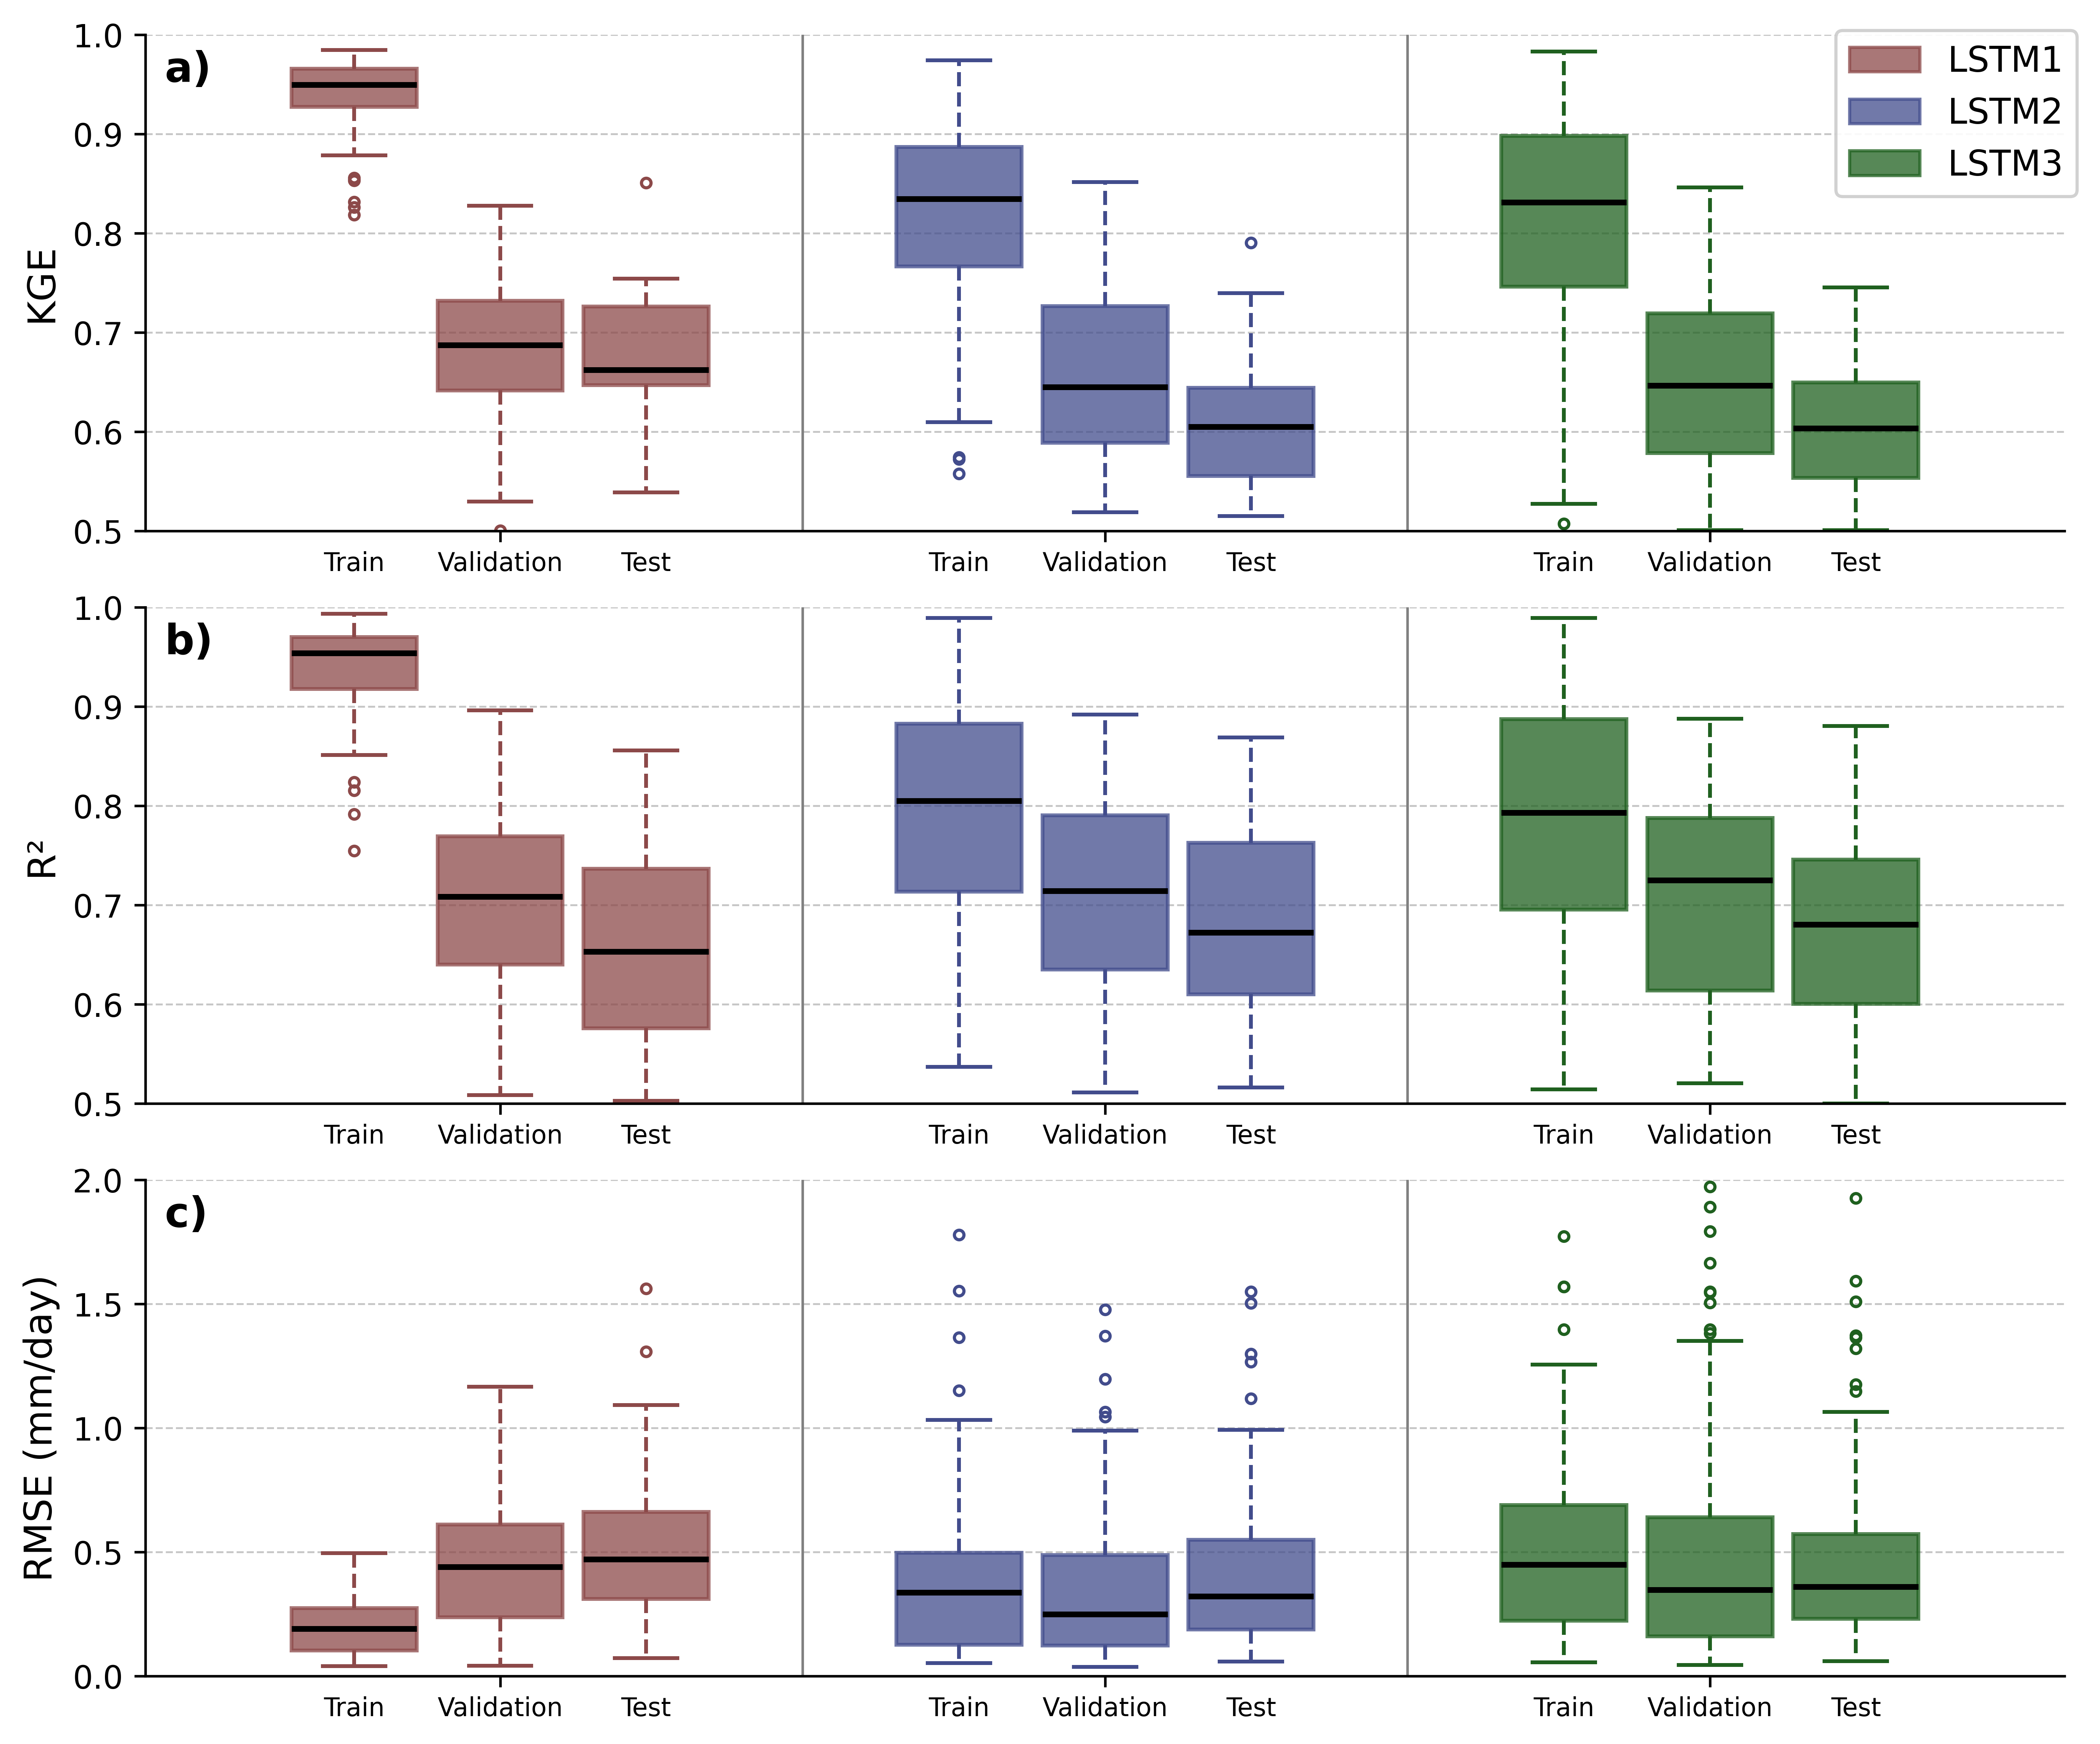

In [3]:
# Chargement
data = {}
for b in budgets:
    data[b] = {}
    for sp, fname in split_files.items():
        df = pd.read_csv(os.path.join(base_dir, b, fname))
        df["R2"] = df["Pearson-r"] ** 2
        data[b][sp] = df

# Positions x
box_w      = 0.3
split_step = box_w + 0.05
group_gap  = 0.4

positions = {}
x = 0
for b in budgets:
    for s in splits:
        positions[(b, s)] = x
        x += split_step
    x += group_gap

tick_pos = [np.mean([positions[(b, s)] for s in splits]) for b in budgets]
sep_xs   = [(positions[(budgets[i], splits[-1])] + positions[(budgets[i+1], splits[0])]) / 2
            for i in range(len(budgets) - 1)]

# Figure
fig, axes = plt.subplots(len(metrics), 1, figsize=(9, 2.5 * len(metrics)),constrained_layout=True, dpi=600)

for row_idx, (ax, metric, ylabel) in enumerate(zip(axes, metrics, ylabels)):
    ymin_lim, ymax_lim = ylims[metric]

    for b in budgets:
        for s in splits:
            vals = data[b][s][metric].dropna().values
            if metric in ("KGE", "R2"):
                vals = vals[vals >= 0.5]
            else:
                vals = vals[vals <= 2.0]
            if len(vals) == 0:
                continue
            ax.boxplot(
                vals,
                positions=[positions[(b, s)]],
                widths=box_w,
                patch_artist=True,
                showfliers=True,
                flierprops=dict(marker="o", markersize=3,markerfacecolor="none",markeredgecolor=colors[b], linewidth=0.7),
                medianprops=dict(color="black", linewidth=1.8),
                whiskerprops=dict(color=colors[b], linewidth=1.2, linestyle="--"),
                capprops=dict(color=colors[b], linewidth=1.2),
                boxprops=dict(facecolor=colors[b], alpha=0.75, edgecolor=colors[b], linewidth=1.2),
            )
                              
    for sx in sep_xs:
        ax.axvline(sx, color="gray", linewidth=0.8, linestyle="-")

    ax.set_xticks(tick_pos)
    ax.set_xticklabels([""] * len(budgets))
    #ax.set_xticklabels(budgets, fontsize=11)
    ax.set_ylim(ymin_lim, ymax_lim)

    offset = (ymax_lim - ymin_lim) * 0.04
    for b in budgets:
        for s in splits:
            ax.text(positions[(b, s)], ymin_lim - offset, s, ha="center", va="top", fontsize=8)

    ax.text(0.01, 0.97, f"{chr(97 + row_idx)})",
            transform=ax.transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
    ax.set_ylabel(ylabel, fontsize=12)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.03)

legend_handles = [
    mpatches.Patch(facecolor=colors[b], alpha=0.75, edgecolor=colors[b], label=budget_labels[b])
    for b in budgets
]
fig.legend(handles=legend_handles, loc="upper right",bbox_to_anchor=(1.01, 1.0), fontsize=11, title="", framealpha=0.9)

plt.show()
